In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("./selfies_ready.csv")

In [3]:
df

,assay_id,doc_id,description,assay_type,assay_organism,tid,confidence_score,curated_by,src_assay_id,chembl_id,src_id,concatenated_value,relation,site_name,selfies
0,76114,14575,Inhibition of HIV-1 protease in a cell culture...,Functional,Human immunodeficiency virus 1,191,9,Expert,NaN,CHEMBL684614,1,IC50 2.300000000000000000000000000000 uM,=,"Human immunodeficiency virus type 1 protease, ...",[C][C][C][C][Branch1][O][C][C][C][=C][C][=C][C...
1,76114,14575,Inhibition of HIV-1 protease in a cell culture...,Functional,Human immunodeficiency virus 1,191,9,Expert,NaN,CHEMBL684614,1,IC50 0.110000000000000000000000000000 uM,=,"Human immunodeficiency virus type 1 protease, ...",[C][C][C][C@][Branch1][O][C][C][C][=C][C][=C][...
2,76114,14575,Inhibition of HIV-1 protease in a cell culture...,Functional,Human immunodeficiency virus 1,191,9,Expert,NaN,CHEMBL684614,1,IC50 1.800000000000000000000000000000 uM,=,"Human immunodeficiency virus type 1 protease, ...",[C][C][C][Branch2][Ring1][=N][C][=C][Branch1][...
3,76114,14575,Inhibition of HIV-1 protease in a cell culture...,Functional,Human immunodeficiency virus 1,191,9,Expert,NaN,CHEMBL684614,1,IC50 0.580000000000000000000000000000 uM,=,"Human immunodeficiency virus type 1 protease, ...",[C][C][C][C@][Branch1][O][C][C][C][=C][C][=C][...
4,76114,14575,Inhibition of HIV-1 protease in a cell culture...,Functional,Human immunodeficiency virus 1,191,9,Expert,NaN,CHEMBL684614,1,IC50 0.500000000000000000000000000000 uM,=,"Human immunodeficiency virus type 1 protease, ...",[C][C][C][C][Branch1][O][C][C][C][=C][C][=C][C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6628,2185970,122513,Inhibition of recombinant His-tagged HIV-1 NL4...,Binding,Human immunodeficiency virus 1,12456,9,Autocuration,NaN,CHEMBL5098052,1,IC50 0.019000000000000000000000000000 uM,=,"Human immunodeficiency virus type 1 integrase,...",[C][C][=N][N][=C][Branch2][Ring2][P][C][=Branc...
6629,2201733,123020,Inhibition of recombinant HIV-1 subtype C inte...,Binding,Human immunodeficiency virus 1,12456,9,Autocuration,NaN,CHEMBL5114441,1,IC50 4.650000000000000000000000000000 uM,=,"Human immunodeficiency virus type 1 integrase,...",[C][O][C][=C][C][=C][Branch1][=Branch2][C][Bra...
6630,2201733,123020,Inhibition of recombinant HIV-1 subtype C inte...,Binding,Human immunodeficiency virus 1,12456,9,Autocuration,NaN,CHEMBL5114441,1,IC50 18.300000000000000000000000000000 uM,=,"Human immunodeficiency virus type 1 integrase,...",[C][C][=Branch1][C][=O][N][C@H1][C@H1][Branch2...
6631,2249495,124586,Inhibition of recombinant HIV-1 integrase stra...,Binding,Human immunodeficiency virus 1,12456,9,Autocuration,NaN,CHEMBL5163705,1,IC50 0.015000000000000000000000000000 uM,=,"Human immunodeficiency virus type 1 integrase,...",[C][C][=N][N][=C][Branch2][Ring2][P][C][=Branc...


In [4]:
import selfies as sf

In [7]:
sf.decoder(
    "[Br].[O][=C][NH1][C][=C][Branch1][=Branch2][C][=Branch1][C][=O][N][Ring1][#Branch1][O][C][C][C][N][C][C][Ring1][=Branch1][S][Ring1][=N]"
)

'Br.O=C1[NH1]C2=C(C(=O)N1O)C3CCNCC3S2'

In [6]:
list(
    sf.split_selfies(
        "[Br].[O][=C][NH1][C][=C][Branch1][=Branch2][C][=Branch1][C][=O][N][Ring1][#Branch1][O][C][C][C][N][C][C][Ring1][=Branch1][S][Ring1][=N]"
    )
)

['[Br]',
 '.',
 '[O]',
 '[=C]',
 '[NH1]',
 '[C]',
 '[=C]',
 '[Branch1]',
 '[=Branch2]',
 '[C]',
 '[=Branch1]',
 '[C]',
 '[=O]',
 '[N]',
 '[Ring1]',
 '[#Branch1]',
 '[O]',
 '[C]',
 '[C]',
 '[C]',
 '[N]',
 '[C]',
 '[C]',
 '[Ring1]',
 '[=Branch1]',
 '[S]',
 '[Ring1]',
 '[=N]']

In [10]:
from rdkit import Chem
from rdkit.Chem import Draw

In [14]:
m1 = Chem.MolFromSmiles("Br.O=C1[NH1]C2=C(C(=O)N1O)C3CCNCC3S2")

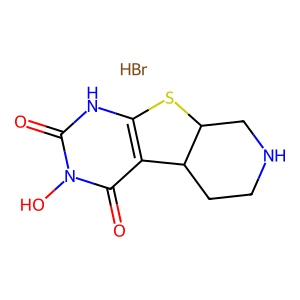

In [15]:
img = Draw.MolToImage(m1)
img

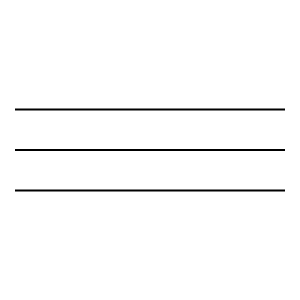

In [22]:
m2 = Chem.MolFromSmiles("C#C")
img2 = Draw.MolToImage(m2)
img2

In [23]:
sf.encoder("C[N+](C)(C)C.FC(F)(F)C(F)(F)[P-](F)(F)(F)(C(F)(F)C(F)(F)F)C(F)(F)C(F)(F)F")

EncoderError: input violates the currently-set semantic constraints
	SMILES: C[N+](C)(C)C.FC(F)(F)C(F)(F)[P-](F)(F)(F)(C(F)(F)C(F)(F)F)C(F)(F)C(F)(F)F
	Errors:
	[[P-1] with 6 bond(s) - a max. of 4 bond(s) was specified]


In [24]:
import psutil

psutil.cpu_count(logical=False)

6

In [25]:
sf.get_semantic_constraints()  # can change P-1 to 6? Idk if logically good.

{'H': 1,
 'F': 1,
 'Cl': 1,
 'Br': 1,
 'I': 1,
 'B': 3,
 'B+1': 2,
 'B-1': 4,
 'O': 2,
 'O+1': 3,
 'O-1': 1,
 'N': 3,
 'N+1': 4,
 'N-1': 2,
 'C': 4,
 'C+1': 5,
 'C-1': 3,
 'P': 5,
 'P+1': 6,
 'P-1': 4,
 'S': 6,
 'S+1': 7,
 'S-1': 5,
 '?': 8}

## Explore

In [26]:
sf.decoder("[C][Branch1_2][Ring2][=C][C][C][Cl]")

DecoderError: invalid symbol '[Branch1_2]'
	SELFIES: [C][Branch1_2][Ring2][=C][C][C][Cl]

In [27]:
smiles = (
    "CN1C(=O)C2=C(c3cc4c(s3)-c3sc(-c5ncc(C#N)s5)cc3C43OCCO3)N(C)C(=O)"
    "C2=C1c1cc2c(s1)-c1sc(-c3ncc(C#N)s3)cc1C21OCCO1"
)
encoded_selfies = sf.encoder(smiles)  # SMILES --> SEFLIES
decoded_smiles = sf.decoder(encoded_selfies)  # SELFIES --> SMILES

In [31]:
from rdkit.Chem import Draw

img = Draw.MolToImage(m)

In [30]:
m = Chem.MolFromSmiles(decoded_smiles)

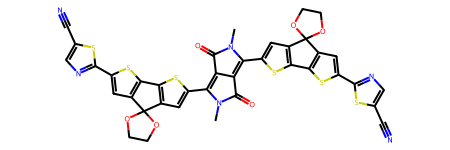

In [32]:
m

In [3]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt


# Hypothetical function to query ChEMBL database
def query_chembl(excluded_tids):
    # Pseudocode for SQL query to select SMILES from ChEMBL where tid not in excluded_tids
    query = f"""
    SELECT DISTINCT canonical_smiles FROM activities
    JOIN assays ON activities.assay_id = assays.assay_id
    WHERE assays.tid NOT IN {tuple(excluded_tids)}
    AND activities.standard_type = 'IC50'
    """
    results = execute_sql_query(query)  # This function would execute the SQL query
    return [row[0] for row in results]


# Function to draw SMILES
def draw_smiles(smiles_list):
    mols = [Chem.MolFromSmiles(smile) for smile in smiles_list]
    img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), useSVG=True)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


# Example usage
excluded_tids = [191, 12456]
smiles = query_chembl(excluded_tids)
draw_smiles(smiles[:16])  # Draw the first 16 molecules

NameError: name 'execute_sql_query' is not defined

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw
import csv  # Import csv module


# Hypothetical function to query ChEMBL database
def query_chembl(excluded_tids):
    # Pseudocode for SQL query to select SMILES from ChEMBL where tid not in excluded_tids
    query = f"""
    SELECT DISTINCT canonical_smiles FROM activities
    JOIN assays ON activities.assay_id = assays.assay_id
    WHERE assays.tid NOT IN {tuple(excluded_tids)}
    AND activities.standard_type = 'IC50'
    """
    results = execute_sql_query(query)  # This function would execute the SQL query
    return [row[0] for row in results]


# Function to draw SMILES
def draw_smiles(smiles_list):
    mols = [Chem.MolFromSmiles(smile) for smile in smiles_list]
    img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), useSVG=True)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


# Function to save SMILES to CSV
def save_smiles_to_csv(smiles_list, filename="smiles_data.csv"):
    with open(filename, "w", newline="") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["canonical_smiles"])  # Write the header
        for smile in smiles_list:
            writer.writerow([smile])  # Write each SMILES as a new row


# Example usage
excluded_tids = [191, 12456]
smiles = query_chembl(excluded_tids)
draw_smiles(smiles[:16])  # Draw the first 16 molecules
save_smiles_to_csv(smiles)  # Save all SMILES to CSV

NameError: name 'execute_sql_query' is not defined

In [6]:
import pymysql
import pymysql.cursors
from rdkit import Chem
from rdkit.Chem import Draw


# Function to establish connection to the database
def create_db_connection():
    connection = pymysql.connect(
        host="192.168.68.65",
        user="kollin",
        password="458296",
        database="chembl_33",
        cursorclass=pymysql.cursors.DictCursor,
    )
    return connection


# Function to execute SQL query
def execute_sql_query(query):
    connection = create_db_connection()
    try:
        with connection.cursor() as cursor:
            cursor.execute(query)
            results = cursor.fetchall()  # Fetch all results
            return [result["canonical_smiles"] for result in results]
    finally:
        connection.close()


# Function to query ChEMBL database
def query_chembl(excluded_tids):
    query = f"""
    SELECT DISTINCT canonical_smiles FROM activities
    JOIN assays ON activities.assay_id = assays.assay_id
    WHERE assays.tid NOT IN {tuple(excluded_tids)}
    AND activities.standard_type = 'IC50'
    """
    return execute_sql_query(query)


# Function to draw SMILES
def draw_smiles(smiles_list):
    mols = [Chem.MolFromSmiles(smile) for smile in smiles_list]
    img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), useSVG=True)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


# Function to save SMILES to CSV
def save_smiles_to_csv(smiles_list, filename="vocab_smiles_data.csv"):
    with open(filename, "w", newline="") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["canonical_smiles"])  # Write the header
        for smile in smiles_list:
            writer.writerow([smile])  # Write each SMILES as a new row


# Example usage
excluded_tids = [191, 12456]
smiles = query_chembl(excluded_tids)
draw_smiles(smiles[:16])  # Draw the first 16 molecules
save_smiles_to_csv(smiles)  # Save all SMILES to CSV

OperationalError: (2003, "Can't connect to MySQL server on '192.168.68.65' ([WinError 10061] No connection could be made because the target machine actively refused it)")

In [ ]:
bbb

## Get distributions

In [2]:
import pandas as pd

In [3]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors


# Function to compute properties
def compute_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        num_carbons = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == "C")
        chain_length = max(
            len(chain)
            for chain in Chem.rdmolops.GetMolFrags(
                mol, asMols=True, sanitizeFrags=False
            )
        )
        cLogP = Descriptors.MolLogP(mol)
        return {
            "SMILES": smiles,
            "Num_Carbons": num_carbons,
            "Chain_Length": chain_length,
            "cLogP": cLogP,
        }
    else:
        return {
            "SMILES": smiles,
            "Num_Carbons": None,
            "Chain_Length": None,
            "cLogP": None,
        }


# Load CSV file
df = pd.read_csv("./33__Attempt_to_do_more_Druglike_molecules.csv")

# Ensure the 'canonical_smiles' column exists
if "canonical_smiles" not in df.columns:
    raise ValueError(
        "The input CSV file must contain a column named 'canonical_smiles'"
    )

# Compute properties for all SMILES
properties = [compute_properties(smiles) for smiles in df["canonical_smiles"]]

# Create DataFrame from computed properties
properties_df = pd.DataFrame(properties)

# Print the DataFrame
print(properties_df)

# Plot distributions
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Number of Carbons distribution
axs[0].hist(
    properties_df["Num_Carbons"].dropna(),
    bins=range(1, properties_df["Num_Carbons"].max() + 2),
    edgecolor="black",
)
axs[0].set_title("Distribution of Number of Carbons")
axs[0].set_xlabel("Number of Carbons")
axs[0].set_ylabel("Frequency")

# Chain Length distribution
axs[1].hist(
    properties_df["Chain_Length"].dropna(),
    bins=range(1, properties_df["Chain_Length"].max() + 2),
    edgecolor="black",
)
axs[1].set_title("Distribution of Chain Length")
axs[1].set_xlabel("Chain Length")
axs[1].set_ylabel("Frequency")

# cLogP distribution
axs[2].hist(properties_df["cLogP"].dropna(), bins=10, edgecolor="black")
axs[2].set_title("Distribution of cLogP")
axs[2].set_xlabel("cLogP")
axs[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

TypeError: object of type 'Mol' has no len()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem


# Function to compute properties
def compute_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        num_carbons = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == "C")
        chain_lengths = [len(fragment) for fragment in Chem.rdmolops.GetMolFrags(mol)]
        chain_length = max(chain_lengths) if chain_lengths else 0
        cLogP = Descriptors.MolLogP(mol)
        return {
            "SMILES": smiles,
            "Num_Carbons": num_carbons,
            "Chain_Length": chain_length,
            "cLogP": cLogP,
        }
    else:
        return {
            "SMILES": smiles,
            "Num_Carbons": None,
            "Chain_Length": None,
            "cLogP": None,
        }


# Load CSV file
df = pd.read_csv("./33__Attempt_to_do_more_Druglike_molecules.csv")

# Ensure the 'canonical_smiles' column exists
if "canonical_smiles" not in df.columns:
    raise ValueError(
        "The input CSV file must contain a column named 'canonical_smiles'"
    )

# Compute properties for all SMILES
properties = [compute_properties(smiles) for smiles in df["canonical_smiles"]]

# Create DataFrame from computed properties
properties_df = pd.DataFrame(properties)

# Print the DataFrame
print(properties_df)

# Plot distributions
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Number of Carbons distribution
axs[0].hist(
    properties_df["Num_Carbons"].dropna(),
    bins=range(1, properties_df["Num_Carbons"].max() + 2),
    edgecolor="black",
)
axs[0].set_title("Distribution of Number of Carbons")
axs[0].set_xlabel("Number of Carbons")
axs[0].set_ylabel("Frequency")

# Chain Length distribution
axs[1].hist(
    properties_df["Chain_Length"].dropna(),
    bins=range(1, properties_df["Chain_Length"].max() + 2),
    edgecolor="black",
)
axs[1].set_title("Distribution of Chain Length")
axs[1].set_xlabel("Chain Length")
axs[1].set_ylabel("Frequency")

# cLogP distribution
axs[2].hist(properties_df["cLogP"].dropna(), bins=10, edgecolor="black")
axs[2].set_title("Distribution of cLogP")
axs[2].set_xlabel("cLogP")
axs[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem


# Function to compute properties
def compute_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        num_carbons = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == "C")
        chain_lengths = [len(fragment) for fragment in Chem.rdmolops.GetMolFrags(mol)]
        chain_length = max(chain_lengths) if chain_lengths else 0
        cLogP = Descriptors.MolLogP(mol)
        num_rings = mol.GetRingInfo().NumRings()
        return {
            "SMILES": smiles,
            "Num_Carbons": num_carbons,
            "Chain_Length": chain_length,
            "cLogP": cLogP,
            "Num_Rings": num_rings,
        }
    else:
        return {
            "SMILES": smiles,
            "Num_Carbons": None,
            "Chain_Length": None,
            "cLogP": None,
            "Num_Rings": None,
        }


# Load CSV file
df = pd.read_csv("./33__Attempt_to_do_more_Druglike_molecules.csv")

# Ensure the 'canonical_smiles' column exists
if "canonical_smiles" not in df.columns:
    raise ValueError(
        "The input CSV file must contain a column named 'canonical_smiles'"
    )

# Compute properties for all SMILES
properties = [compute_properties(smiles) for smiles in df["canonical_smiles"]]

# Create DataFrame from computed properties
properties_df = pd.DataFrame(properties)

# Print the DataFrame
print(properties_df)

# Plot distributions
fig, axs = plt.subplots(1, 4, figsize=(24, 6))

# Number of Carbons distribution
axs[0].hist(
    properties_df["Num_Carbons"].dropna(),
    bins=range(1, properties_df["Num_Carbons"].max() + 2),
    edgecolor="black",
)
axs[0].set_title("Distribution of Number of Carbons")
axs[0].set_xlabel("Number of Carbons")
axs[0].set_ylabel("Frequency")

# Chain Length distribution
axs[1].hist(
    properties_df["Chain_Length"].dropna(),
    bins=range(1, properties_df["Chain_Length"].max() + 2),
    edgecolor="black",
)
axs[1].set_title("Distribution of Chain Length")
axs[1].set_xlabel("Chain Length")
axs[1].set_ylabel("Frequency")

# cLogP distribution
axs[2].hist(properties_df["cLogP"].dropna(), bins=10, edgecolor="black")
axs[2].set_title("Distribution of cLogP")
axs[2].set_xlabel("cLogP")
axs[2].set_ylabel("Frequency")

# Number of Rings distribution
axs[3].hist(
    properties_df["Num_Rings"].dropna(),
    bins=range(1, properties_df["Num_Rings"].max() + 2),
    edgecolor="black",
)
axs[3].set_title("Distribution of Number of Rings")
axs[3].set_xlabel("Number of Rings")
axs[3].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [5]:
df

,canonical_smiles
0,c1ccc(-c2nc3c(-c4nc5ccccc5o4)cccc3o2)cc1
1,Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...
2,COc1ccccc1-c1ccc2oc(-c3ccc(OC)c(N4C(=O)c5ccc(C...
3,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(Cl)c(C(...
4,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)NCCc4ccccc4)CC...
...,...
938546,C=C(C)[C@]12C[C@@H](C)[C@@]34O[C@@]5(CCCCCCC[C...
938547,C=C(C)[C@]12C[C@@H](C)[C@@]34OC5(CCCCCCC[C@@H]...
938548,C=C(C)[C@]12C[C@@H](COC(=O)c3ccccc3)[C@]34OC5(...
938549,C=C(C)[C@]12C[C@@H](COC(=O)c3ccccc3)[C@]34OC5(...


                                                   SMILES  Num_Carbons  \
0                c1ccc(-c2nc3c(-c4nc5ccccc5o4)cccc3o2)cc1           20   
1       Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...           23   
2       COc1ccccc1-c1ccc2oc(-c3ccc(OC)c(N4C(=O)c5ccc(C...           30   
3       Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(Cl)c(C(...           24   
4       Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)NCCc4ccccc4)CC...           25   
...                                                   ...          ...   
938546  C=C(C)[C@]12C[C@@H](C)[C@@]34O[C@@]5(CCCCCCC[C...           30   
938547  C=C(C)[C@]12C[C@@H](C)[C@@]34OC5(CCCCCCC[C@@H]...           30   
938548  C=C(C)[C@]12C[C@@H](COC(=O)c3ccccc3)[C@]34OC5(...           37   
938549  C=C(C)[C@]12C[C@@H](COC(=O)c3ccccc3)[C@]34OC5(...           37   
938550  C=C(C)[C@]12C[C@@H](COC(=O)c3ccccc3)[C@]34OC5(...           44   

        Chain_Length    cLogP  Num_Rings  
0                 24  5.30300          5  
1                 30  4.3

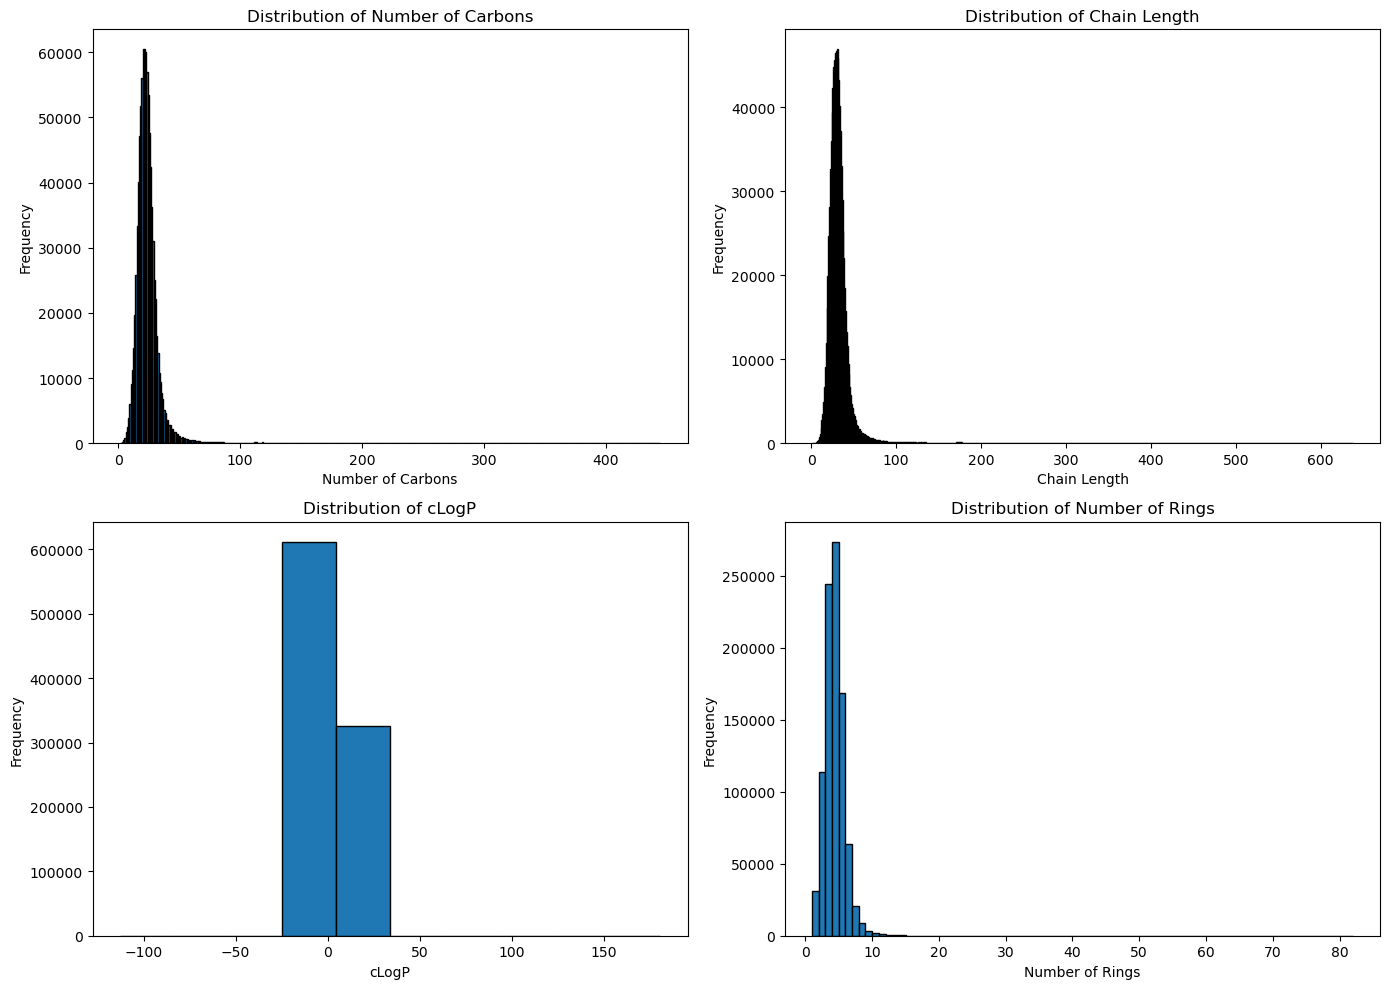

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem


# Function to compute properties
def compute_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        num_carbons = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == "C")
        chain_lengths = [len(fragment) for fragment in Chem.rdmolops.GetMolFrags(mol)]
        chain_length = max(chain_lengths) if chain_lengths else 0
        cLogP = Descriptors.MolLogP(mol)
        num_rings = mol.GetRingInfo().NumRings()
        return {
            "SMILES": smiles,
            "Num_Carbons": num_carbons,
            "Chain_Length": chain_length,
            "cLogP": cLogP,
            "Num_Rings": num_rings,
        }
    else:
        return {
            "SMILES": smiles,
            "Num_Carbons": None,
            "Chain_Length": None,
            "cLogP": None,
            "Num_Rings": None,
        }


# Load CSV file
df = pd.read_csv("./33__Attempt_to_do_more_Druglike_molecules-Copy1.csv")

# Ensure the 'canonical_smiles' column exists
if "canonical_smiles" not in df.columns:
    raise ValueError(
        "The input CSV file must contain a column named 'canonical_smiles'"
    )

# Compute properties for all SMILES
properties = [compute_properties(smiles) for smiles in df["canonical_smiles"]]

# Create DataFrame from computed properties
properties_df = pd.DataFrame(properties)

# Print the DataFrame
print(properties_df)

# Plot distributions
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Number of Carbons distribution
axs[0, 0].hist(
    properties_df["Num_Carbons"].dropna(),
    bins=range(1, properties_df["Num_Carbons"].max() + 2),
    range=[properties_df["Num_Carbons"].min(), properties_df["Num_Carbons"].max()],
    edgecolor="black",
)
axs[0, 0].set_title("Distribution of Number of Carbons")
axs[0, 0].set_xlabel("Number of Carbons")
axs[0, 0].set_ylabel("Frequency")

# Chain Length distribution
axs[0, 1].hist(
    properties_df["Chain_Length"].dropna(),
    bins=range(1, properties_df["Chain_Length"].max() + 2),
    range=[properties_df["Chain_Length"].min(), properties_df["Chain_Length"].max()],
    edgecolor="black",
)
axs[0, 1].set_title("Distribution of Chain Length")
axs[0, 1].set_xlabel("Chain Length")
axs[0, 1].set_ylabel("Frequency")

# cLogP distribution
axs[1, 0].hist(
    properties_df["cLogP"].dropna(),
    bins=10,
    range=[properties_df["cLogP"].min(), properties_df["cLogP"].max()],
    edgecolor="black",
)
axs[1, 0].set_title("Distribution of cLogP")
axs[1, 0].set_xlabel("cLogP")
axs[1, 0].set_ylabel("Frequency")

# Number of Rings distribution
axs[1, 1].hist(
    properties_df["Num_Rings"].dropna(),
    bins=range(1, properties_df["Num_Rings"].max() + 2),
    range=[properties_df["Num_Rings"].min(), properties_df["Num_Rings"].max()],
    edgecolor="black",
)
axs[1, 1].set_title("Distribution of Number of Rings")
axs[1, 1].set_xlabel("Number of Rings")
axs[1, 1].set_ylabel("Frequency")

plt.tight_layout()

fig.savefig("./FiguresDist_updated.png")
plt.show()

In [12]:
properties_df

,SMILES,Num_Carbons,Chain_Length,cLogP,Num_Rings
0,c1ccc(-c2nc3c(-c4nc5ccccc5o4)cccc3o2)cc1,20,24,5.30300,5
1,Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...,23,30,4.30202,5
2,COc1ccccc1-c1ccc2oc(-c3ccc(OC)c(N4C(=O)c5ccc(C...,30,39,5.67780,6
3,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(Cl)c(C(...,24,36,4.27292,4
4,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)NCCc4ccccc4)CC...,25,33,2.32092,4
...,...,...,...,...,...
938546,C=C(C)[C@]12C[C@@H](C)[C@@]34O[C@@]5(CCCCCCC[C...,30,38,2.86260,7
938547,C=C(C)[C@]12C[C@@H](C)[C@@]34OC5(CCCCCCC[C@@H]...,30,38,2.86260,7
938548,C=C(C)[C@]12C[C@@H](COC(=O)c3ccccc3)[C@]34OC5(...,37,48,3.79180,9
938549,C=C(C)[C@]12C[C@@H](COC(=O)c3ccccc3)[C@]34OC5(...,37,48,3.79180,9


In [15]:
print(properties_df["Num_Carbons"].min())
print(properties_df["Num_Carbons"].max())

0
444


In [16]:
print(properties_df["Chain_Length"].min())
print(properties_df["Chain_Length"].max())

1
637


In [17]:
print(properties_df["cLogP"].min())
print(properties_df["cLogP"].max())

-113.01099999999936
180.5171999999962


In [18]:
print(properties_df["Num_Rings"].min())
print(properties_df["Num_Rings"].max())

0
81


In [23]:
properties_df

,SMILES,Num_Carbons,Chain_Length,cLogP,Num_Rings
0,c1ccc(-c2nc3c(-c4nc5ccccc5o4)cccc3o2)cc1,20,24,5.30300,5
1,Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...,23,30,4.30202,5
2,COc1ccccc1-c1ccc2oc(-c3ccc(OC)c(N4C(=O)c5ccc(C...,30,39,5.67780,6
3,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(Cl)c(C(...,24,36,4.27292,4
4,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)NCCc4ccccc4)CC...,25,33,2.32092,4
...,...,...,...,...,...
938546,C=C(C)[C@]12C[C@@H](C)[C@@]34O[C@@]5(CCCCCCC[C...,30,38,2.86260,7
938547,C=C(C)[C@]12C[C@@H](C)[C@@]34OC5(CCCCCCC[C@@H]...,30,38,2.86260,7
938548,C=C(C)[C@]12C[C@@H](COC(=O)c3ccccc3)[C@]34OC5(...,37,48,3.79180,9
938549,C=C(C)[C@]12C[C@@H](COC(=O)c3ccccc3)[C@]34OC5(...,37,48,3.79180,9


In [26]:
# df[['A', 'B']]
properties_df.SMILES[:1]

0    c1ccc(-c2nc3c(-c4nc5ccccc5o4)cccc3o2)cc1
Name: SMILES, dtype: object

In [29]:
properties_df.Num_Carbons.max()

AttributeError: 'numpy.int64' object has no attribute 'index'

In [30]:
properties_df.Num_Carbons[440:446]

440    18
441    17
442    16
443    20
444    22
445    21
Name: Num_Carbons, dtype: int64

In [37]:
max_nCs = properties_df["Num_Carbons"].max()
max_nCs

444

In [38]:
max_index = properties_df["Num_Carbons"].idxmax()
max_index

291756

In [55]:
max_nRings = properties_df["Num_Rings"].max()
max_nRings

81

In [56]:
max_indexRings = properties_df["Num_Rings"].idxmax()
max_indexRings

278046

In [57]:
smiles_string = properties_df.loc[278046, "SMILES"]
print(smiles_string)

O=C1/C(=C/c2ccc(OCc3cc(OCc4cc(OCc5cc(OCc6ccc(-n7c8ccccc8c8ccccc87)cc6)cc(OCc6ccc(-n7c8ccccc8c8ccccc87)cc6)c5)cc(OCc5cc(OCc6ccc(-n7c8ccccc8c8ccccc87)cc6)cc(OCc6ccc(-n7c8ccccc8c8ccccc87)cc6)c5)c4)cc(OCc4cc(OCc5cc(OCc6ccc(-n7c8ccccc8c8ccccc87)cc6)cc(OCc6ccc(-n7c8ccccc8c8ccccc87)cc6)c5)cc(OCc5ccc(OCc6ccc(-n7c8ccccc8c8ccccc87)cc6)cc5OCc5ccc(-n6c7ccccc7c7ccccc76)cc5)c4)c3)cc2)CCC/C1=C\c1ccc(OCc2cc(OCc3cc(OCc4cc(OCc5ccc(-n6c7ccccc7c7ccccc76)cc5)cc(OCc5ccc(-n6c7ccccc7c7ccccc76)cc5)c4)cc(OCc4cc(OCc5ccc(-n6c7ccccc7c7ccccc76)cc5)cc(OCc5ccc(-n6c7ccccc7c7ccccc76)cc5)c4)c3)cc(OCc3cc(OCc4cc(OCc5ccc(-n6c7ccccc7c7ccccc76)cc5)cc(OCc5ccc(-n6c7ccccc7c7ccccc76)cc5)c4)cc(OCc4ccc(OCc5ccc(-n6c7ccccc7c7ccccc76)cc5)cc4OCc4ccc(-n5c6ccccc6c6ccccc65)cc4)c3)c2)cc1


In [42]:
properties_df[291740:291770]

,SMILES,Num_Carbons,Chain_Length,cLogP,Num_Rings
291740,COc1cc2c3cc1Oc1c(O)c(OC)cc4ccnc(c14)Cc1ccc(cc1...,35,44,6.9363,8
291741,CCCN(C(=O)C(C)c1cccc(C(=O)c2ccccc2)c1)c1ccc2cc...,27,31,5.9456,4
291742,CCCN(C(=O)C(C)c1cccc(C(=O)c2ccccc2)c1)c1ccc2[n...,27,31,5.9456,4
291743,O=C(Oc1cc(O)cc2c1C[C@H](O)[C@@H](c1ccc(O)c(O)c...,22,32,2.1765,4
291744,O=C(O[C@H]1Cc2c(O)cc(O)cc2O[C@@H]1c1ccc(O)c(O)...,22,32,2.5276,4
291745,CO[C@H]1C[C@@H]([C@@H](O)[C@@](C)(OC)[C@H](C)O...,36,48,3.1992,5
291746,COc1cc(/C=C2/Cc3c(OC(C)=O)cc(OC(C)=O)cc3O2)cc(...,23,32,3.4557,3
291747,COC(C)(C)[C@@H]1C=C2C(=O)[C@H]3O[C@H]3C3C=CC(C...,20,26,0.5848,4
291748,CN(/N=C/c1ccc(OP2(Oc3ccc(/C=N/N(C)P(=S)(Oc4ccc...,168,288,-23.2974,19
291749,CCCC(C(=O)NCCc1ccc(OP(=S)(Oc2ccc(CCNC(=O)C(CCC...,204,324,-9.2730,19


In [48]:
print(properties_df[291756:291757].SMILES)

291756    CCCCCCCCCC(C(=O)NCCc1ccc(OP(=S)(Oc2ccc(CCNC(=O...
Name: SMILES, dtype: object


In [49]:
smiles_string = properties_df.loc[291756, "SMILES"]
print(smiles_string)

CCCCCCCCCC(C(=O)NCCc1ccc(OP(=S)(Oc2ccc(CCNC(=O)C(CCCCCCCCC)P(=O)(O)O)cc2)N(C)/N=C/c2ccc(OP3(Oc4ccc(/C=N/N(C)P(=S)(Oc5ccc(CCNC(=O)C(CCCCCCCCC)P(=O)(O)O)cc5)Oc5ccc(CCNC(=O)C(CCCCCCCCC)P(=O)(O)O)cc5)cc4)=NP(Oc4ccc(/C=N/N(C)P(=S)(Oc5ccc(CCNC(=O)C(CCCCCCCCC)P(=O)(O)O)cc5)Oc5ccc(CCNC(=O)C(CCCCCCCCC)P(=O)(O)O)cc5)cc4)(Oc4ccc(/C=N/N(C)P(=S)(Oc5ccc(CCNC(=O)C(CCCCCCCCC)P(=O)(O)O)cc5)Oc5ccc(CCNC(=O)C(CCCCCCCCC)P(=O)(O)O)cc5)cc4)=NP(Oc4ccc(/C=N/N(C)P(=S)(Oc5ccc(CCNC(=O)C(CCCCCCCCC)P(=O)(O)O)cc5)Oc5ccc(CCNC(=O)C(CCCCCCCCC)P(=O)(O)O)cc5)cc4)(Oc4ccc(/C=N/N(C)P(=S)(Oc5ccc(CCNC(=O)C(CCCCCCCCC)P(=O)(O)O)cc5)Oc5ccc(CCNC(=O)C(CCCCCCCCC)P(=O)(O)O)cc5)cc4)=N3)cc2)cc1)P(=O)(O)O.CCCCCCCCCCCCCCCCNOC(CO)C(O)C(OC1OC(CO)C(O)C(O)C1O)C(O)CO.CCCCCCCCCCCCCCCCNOC(CO)C(O)C(OC1OC(CO)C(O)C(O)C1O)C(O)CO.CCCCCCCCCCCCCCCCNOC(CO)C(O)C(OC1OC(CO)C(O)C(O)C1O)C(O)CO.CCCCCCCCCCCCCCCCNOC(CO)C(O)C(OC1OC(CO)C(O)C(O)C1O)C(O)CO.CCCCCCCCCCCCCCCCNOC(CO)C(O)C(OC1OC(CO)C(O)C(O)C1O)C(O)CO.CCCCCCCCCCCCCCCCNOC(CO)C(O)C(OC1OC(CO)C(O)C(O)C1O)C

In [50]:
from rdkit import Chem

In [58]:
m = Chem.MolFromSmiles(smiles_string)

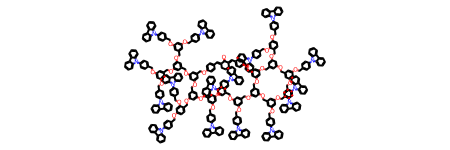

In [59]:
m

In [60]:
from rdkit.Chem import Draw

img = Draw.MolToImage(m)

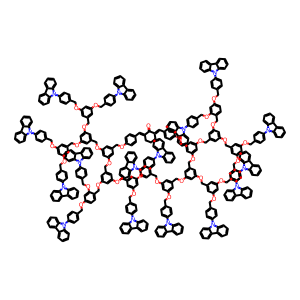

In [61]:
img

                                                   SMILES  Num_Carbons  \
0                c1ccc(-c2nc3c(-c4nc5ccccc5o4)cccc3o2)cc1           20   
1       Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...           23   
2       COc1ccccc1-c1ccc2oc(-c3ccc(OC)c(N4C(=O)c5ccc(C...           30   
3       Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(Cl)c(C(...           24   
4       Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)NCCc4ccccc4)CC...           25   
...                                                   ...          ...   
938546  C=C(C)[C@]12C[C@@H](C)[C@@]34O[C@@]5(CCCCCCC[C...           30   
938547  C=C(C)[C@]12C[C@@H](C)[C@@]34OC5(CCCCCCC[C@@H]...           30   
938548  C=C(C)[C@]12C[C@@H](COC(=O)c3ccccc3)[C@]34OC5(...           37   
938549  C=C(C)[C@]12C[C@@H](COC(=O)c3ccccc3)[C@]34OC5(...           37   
938550  C=C(C)[C@]12C[C@@H](COC(=O)c3ccccc3)[C@]34OC5(...           44   

        Chain_Length    cLogP  Num_Rings  
0                 24  5.30300          5  
1                 30  4.3

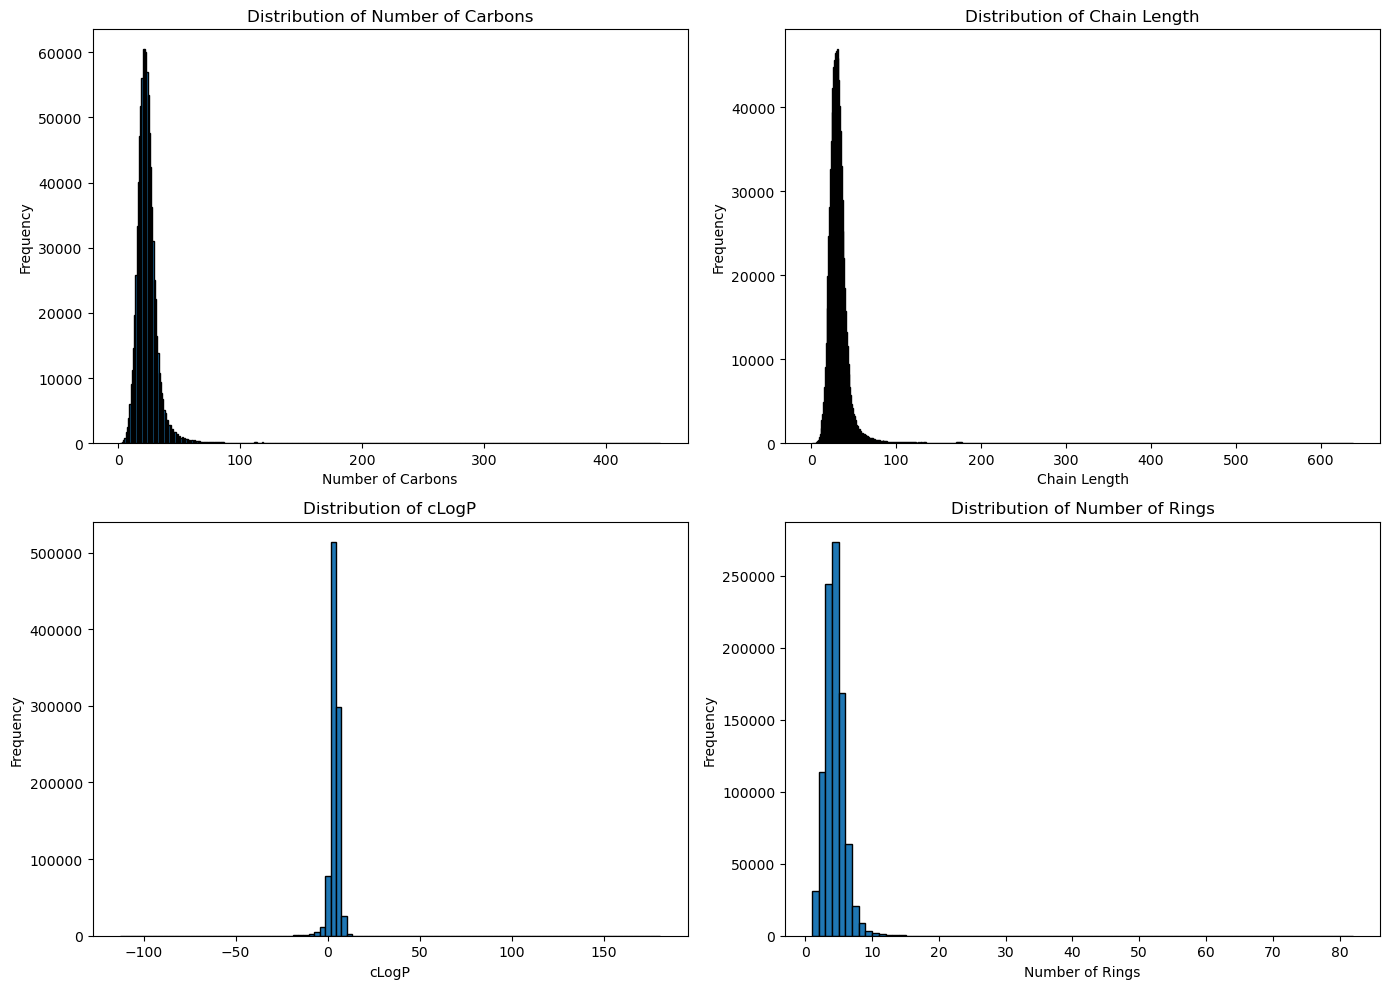

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem


# Function to compute properties
def compute_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        num_carbons = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == "C")
        chain_lengths = [len(fragment) for fragment in Chem.rdmolops.GetMolFrags(mol)]
        chain_length = max(chain_lengths) if chain_lengths else 0
        cLogP = Descriptors.MolLogP(mol)
        num_rings = mol.GetRingInfo().NumRings()
        return {
            "SMILES": smiles,
            "Num_Carbons": num_carbons,
            "Chain_Length": chain_length,
            "cLogP": cLogP,
            "Num_Rings": num_rings,
        }
    else:
        return {
            "SMILES": smiles,
            "Num_Carbons": None,
            "Chain_Length": None,
            "cLogP": None,
            "Num_Rings": None,
        }


# Load CSV file
df = pd.read_csv("./33__Attempt_to_do_more_Druglike_molecules-Copy1.csv")

# Ensure the 'canonical_smiles' column exists
if "canonical_smiles" not in df.columns:
    raise ValueError(
        "The input CSV file must contain a column named 'canonical_smiles'"
    )

# Compute properties for all SMILES
properties = [compute_properties(smiles) for smiles in df["canonical_smiles"]]

# Create DataFrame from computed properties
properties_df = pd.DataFrame(properties)

# Print the DataFrame
print(properties_df)

# Plot distributions
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Number of Carbons distribution
axs[0, 0].hist(
    properties_df["Num_Carbons"].dropna(),
    bins=range(1, properties_df["Num_Carbons"].max() + 2),
    range=[properties_df["Num_Carbons"].min(), properties_df["Num_Carbons"].max()],
    edgecolor="black",
)
axs[0, 0].set_title("Distribution of Number of Carbons")
axs[0, 0].set_xlabel("Number of Carbons")
axs[0, 0].set_ylabel("Frequency")

# Chain Length distribution
axs[0, 1].hist(
    properties_df["Chain_Length"].dropna(),
    bins=range(1, properties_df["Chain_Length"].max() + 2),
    range=[properties_df["Chain_Length"].min(), properties_df["Chain_Length"].max()],
    edgecolor="black",
)
axs[0, 1].set_title("Distribution of Chain Length")
axs[0, 1].set_xlabel("Chain Length")
axs[0, 1].set_ylabel("Frequency")

# cLogP distribution
axs[1, 0].hist(
    properties_df["cLogP"].dropna(),
    bins=100,
    range=[properties_df["cLogP"].min(), properties_df["cLogP"].max()],
    edgecolor="black",
)
axs[1, 0].set_title("Distribution of cLogP")
axs[1, 0].set_xlabel("cLogP")
axs[1, 0].set_ylabel("Frequency")

# Number of Rings distribution
axs[1, 1].hist(
    properties_df["Num_Rings"].dropna(),
    bins=range(1, properties_df["Num_Rings"].max() + 2),
    range=[properties_df["Num_Rings"].min(), properties_df["Num_Rings"].max()],
    edgecolor="black",
)
axs[1, 1].set_title("Distribution of Number of Rings")
axs[1, 1].set_xlabel("Number of Rings")
axs[1, 1].set_ylabel("Frequency")

plt.tight_layout()

fig.savefig("./FiguresDist_updated_cLogPBins_meh.png")
plt.show()

In [80]:
# Function to compute properties
def compute_MW(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        MW = Descriptors.MolWt(mol)
        return {"SMILES": smiles, "MW": MW}
    else:
        return {"SMILES": smiles, "MW": None}

In [81]:
# Load CSV file
df = pd.read_csv("./33__Attempt_to_do_more_Druglike_molecules-Copy1.csv")

# Ensure the 'canonical_smiles' column exists
if "canonical_smiles" not in df.columns:
    raise ValueError(
        "The input CSV file must contain a column named 'canonical_smiles'"
    )

# Compute properties for all SMILES
MolWeights = [compute_MW(smiles) for smiles in df["canonical_smiles"]]

In [85]:
MolWeights_df = pd.DataFrame(MolWeights)

In [91]:
MolWeights_df.MW.max()

12546.317999999916

In [94]:
newArray = MolWeights_df[MolWeights_df.MW < 550]

In [95]:
newArray.shape

(791492, 2)

In [99]:
filtered_newArray = newArray.drop("MW", axis=1)

In [101]:
filtered_newArray.to_csv(
    "FILTERED_UNDER_550MW_33__Attempt_to_do_more_Druglike_molecules-Copy1.csv"
)

In [103]:
df = pd.read_csv(
    "FILTERED_UNDER_550MW_33__Attempt_to_do_more_Druglike_molecules-Copy1.csv"
)

In [108]:
df = df.drop("Unnamed: 0", axis=1)

In [109]:
df

,SMILES
0,c1ccc(-c2nc3c(-c4nc5ccccc5o4)cccc3o2)cc1
1,Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...
2,COc1ccccc1-c1ccc2oc(-c3ccc(OC)c(N4C(=O)c5ccc(C...
3,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(Cl)c(C(...
4,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)NCCc4ccccc4)CC...
...,...
791487,C=C(C)[C@]12C[C@@H](C)[C@]34OC5(CCCCCCC[C@H](C...
791488,C=C(C)[C@]12C[C@@H](C)[C@]34OC5(CCCCCCC[C@@H](...
791489,C=C(C)[C@]12C[C@@H](C)[C@@]34OC5(CCCCCCCC[C@H]...
791490,C=C(C)[C@]12C[C@@H](C)[C@@]34O[C@@]5(CCCCCCC[C...


In [110]:
MolWeights = [compute_MW(smiles) for smiles in df["SMILES"]]

In [111]:
MolWeights_df = pd.DataFrame(MolWeights)

In [117]:
df = MolWeights_df

In [223]:
# Function to compute MW
def compute_MW(canonical_smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        MW = Descriptors.MolWt(mol)
        return {"canonical_smiles": canonical_smiles, "MW": MW}
    else:
        return {"canonical_smiles": canonical_smiles, "MW": None}

In [258]:
def compute_properties(canonical_smiles):
    mol = Chem.MolFromSmiles(canonical_smiles)
    if mol:
        num_carbons = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == "C")
        chain_lengths = [len(fragment) for fragment in Chem.rdmolops.GetMolFrags(mol)]
        chain_length = max(chain_lengths) if chain_lengths else 0
        cLogP = Descriptors.MolLogP(mol)
        num_rings = mol.GetRingInfo().NumRings()
        return {
            "canonical_smiles": canonical_smiles,
            "Num_Carbons": num_carbons,
            "Chain_Length": chain_length,
            "cLogP": cLogP,
            "Num_Rings": num_rings,
        }
    else:
        return {
            "canonical_smiles": canonical_smiles,
            "Num_Carbons": None,
            "Chain_Length": None,
            "cLogP": None,
            "Num_Rings": None,
        }

In [225]:
# Function to compute ring counts
def compute_rings(canonical_smiles):
    mol = Chem.MolFromSmiles(canonical_smiles)
    if mol:
        num_rings = mol.GetRingInfo().NumRings()
        return {"canonical_smiles": canonical_smiles, "Num_Rings": num_rings}
    else:
        return {"canonical_smiles": canonical_smiles, "Num_Rings": None}

In [226]:
def filterMW(weight, df):
    MolWeights = [compute_MW(canonical_smiles) for smiles in df["canonical_smiles"]]
    MolWeights_df = pd.DataFrame(MolWeights)
    MolWeights_df = MolWeights_df[MolWeights_df.MW < weight]
    return MolWeights_df

In [227]:
def filterRings(rings, df):
    numRings = [compute_rings(canonical_smiles) for smiles in df["canonical_smiles"]]
    numRings_df = pd.DataFrame(numRings)
    numRings_df = numRings_df[numRings_df.MW < rings]
    return numRings_df

In [213]:
df = pd.read_csv(
    "FILTERED_UNDER_550MW_33__Attempt_to_do_more_Druglike_molecules-Copy1.csv"
)

In [214]:
df = df.drop(
    "Unnamed: 0", axis=1
)  # .to_csv("FILTERED_UNDER_550MW_33__Attempt_to_do_more_Druglike_molecules-Copy2.csv")

In [215]:
df.columns

Index(['SMILES'], dtype='object')

In [216]:
df.to_csv(
    "FILTERED_UNDER_550MW_33__Attempt_to_do_more_Druglike_molecules-Copy2.csv",
    index=False,
)

In [228]:
df = pd.read_csv(
    "FILTERED_UNDER_550MW_33__Attempt_to_do_more_Druglike_molecules-Copy2.csv"
)

In [229]:
df["SMILES"]

0                  c1ccc(-c2nc3c(-c4nc5ccccc5o4)cccc3o2)cc1
1         Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...
2         COc1ccccc1-c1ccc2oc(-c3ccc(OC)c(N4C(=O)c5ccc(C...
3         Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(Cl)c(C(...
4         Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)NCCc4ccccc4)CC...
                                ...                        
791487    C=C(C)[C@]12C[C@@H](C)[C@]34OC5(CCCCCCC[C@H](C...
791488    C=C(C)[C@]12C[C@@H](C)[C@]34OC5(CCCCCCC[C@@H](...
791489    C=C(C)[C@]12C[C@@H](C)[C@@]34OC5(CCCCCCCC[C@H]...
791490    C=C(C)[C@]12C[C@@H](C)[C@@]34O[C@@]5(CCCCCCC[C...
791491    C=C(C)[C@]12C[C@@H](C)[C@@]34OC5(CCCCCCC[C@@H]...
Name: SMILES, Length: 791492, dtype: object

In [230]:
numRings = [compute_rings(canonical_smiles) for canonical_smiles in df["SMILES"]]

In [233]:
numRings = pd.DataFrame(numRings)

In [237]:
numRings.columns

Index(['canonical_smiles', 'Num_Rings'], dtype='object')

In [248]:
numRings2 = numRings[numRings.Num_Rings < 3]

In [250]:
numRings2 = numRings2.drop("Num_Rings", axis=1)

In [251]:
numRings2

,canonical_smiles
14,CC[N+](C)(CC)CC(=O)CCN1C(=O)CCC1=O.[I-]
18,CCN1CCC[C@H]1CNC(=O)c1c(OC)ccc(C)c1O
21,S=C(NCN1CCOCC1)Nc1ccc(Br)cn1
22,Cc1cn([C@H]2C[C@H](N=[N+]=[N-])[C@@H](CO)O2)c(...
24,CC(=O)O[C@@H]1CC(=O)N1C(=O)NC(C)C
...,...
791468,CC(=O)N1CCCc2ccccc21
791469,Cc1cc(-c2ccccc2)cn(C)c1=O
791481,CC(C)=CC[C@@H]1C(=O)c2c(O)ccc(O)c2[C@@H]1O
791482,CC(C)(O)/C=C\C(O)=C1C(=O)c2c(O)ccc(O)c2C1=O


In [260]:
properties = [compute_properties(smiles) for smiles in numRings2["canonical_smiles"]]

In [264]:
properties = pd.DataFrame(properties)

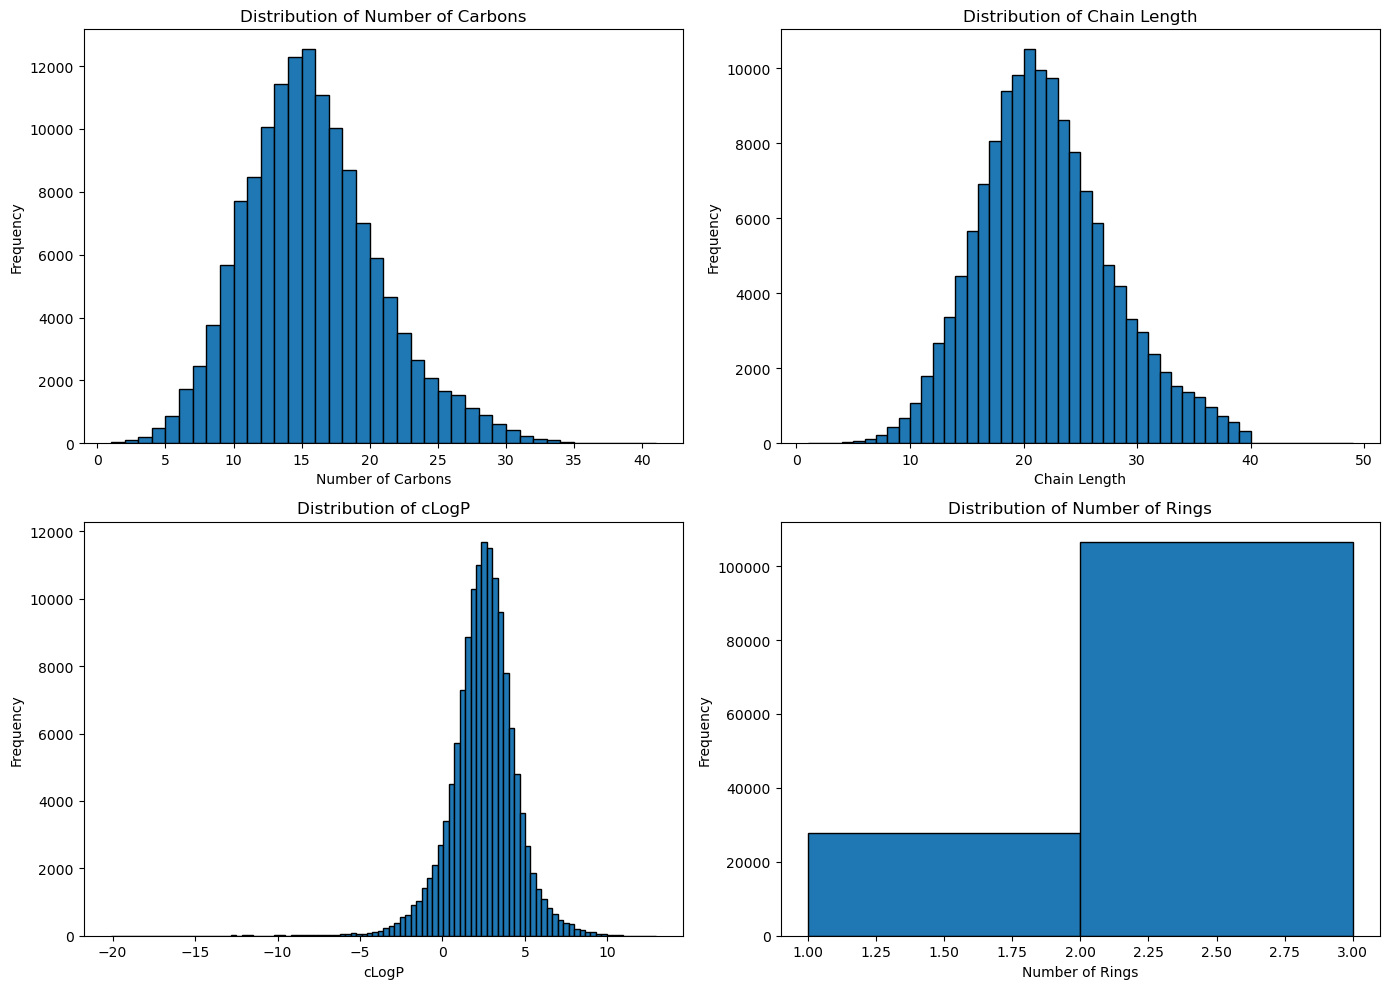

In [265]:
plot_Dist(properties, "Filtered_UNDER_550_3RING.png")

In [271]:
properties.canonical_smiles.sample(n=10)
sampled_properties = pd.DataFrame(properties.canonical_smiles.sample(n=10))

In [272]:
sampled_properties

,canonical_smiles
105978,COc1cc(C=O)cc(-c2cc(C=O)cc(OC)c2O)c1O
135063,CCN(CC)C(=O)/C=C/c1ccc(OCc2ccccc2)c(OC)c1
97020,N#Cc1ccc(S(=O)(=O)NNc2ccc(Br)cc2)cc1
64658,CCCCOC(=O)CSc1nc(N)c(C#N)c(-c2ccc(OCC)cc2)c1C#N
85505,CNC(=O)/C(=C/c1ccc(OC)cc1)c1ccccc1
12211,CCC1C(=O)N2C=CSC2N(CC)C1=O
112669,O=C(N/N=C/c1ccc([N+](=O)[O-])cc1)c1cccnc1
138251,CCOC(=O)c1cc(O)n(-c2ccc(CS(=O)(=O)NC)cc2)n1
29014,CCN1CCC(c2ccccc2)=C(C(=O)OCC(C)C)C1.O=C(O)C(=O)O
15367,CCOc1noc2c1CNCC2.Cl


In [276]:
for mol in sampled_properties.canonical_smiles:
    print(mol)
    m = Chem.MolFromSmiles(mol)
    img = Draw.MolToImage(m)
    img

COc1cc(C=O)cc(-c2cc(C=O)cc(OC)c2O)c1O
CCN(CC)C(=O)/C=C/c1ccc(OCc2ccccc2)c(OC)c1
N#Cc1ccc(S(=O)(=O)NNc2ccc(Br)cc2)cc1
CCCCOC(=O)CSc1nc(N)c(C#N)c(-c2ccc(OCC)cc2)c1C#N
CNC(=O)/C(=C/c1ccc(OC)cc1)c1ccccc1
CCC1C(=O)N2C=CSC2N(CC)C1=O
O=C(N/N=C/c1ccc([N+](=O)[O-])cc1)c1cccnc1
CCOC(=O)c1cc(O)n(-c2ccc(CS(=O)(=O)NC)cc2)n1
CCN1CCC(c2ccccc2)=C(C(=O)OCC(C)C)C1.O=C(O)C(=O)O
CCOc1noc2c1CNCC2.Cl


In [280]:
def sample_and_print(numSamples, df):
    temp = df.canonical_smiles.sample(n=numSamples)
    sampled_properties = pd.DataFrame(temp)
    for mol in sampled_properties.canonical_smiles:
        print(mol)
        m = Chem.MolFromSmiles(mol)
        if m:  # Ensure the molecule was created successfully
            img = Draw.MolToImage(m)
            display(img)

CC(O)(COc1ccc(OC(F)(F)F)cc1)C(=O)Nc1ccc(C#N)cc1C(F)(F)F


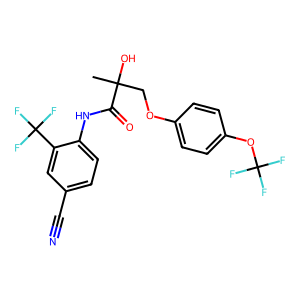

O=C(Nc1ncc([N+](=O)[O-])s1)c1ccccc1


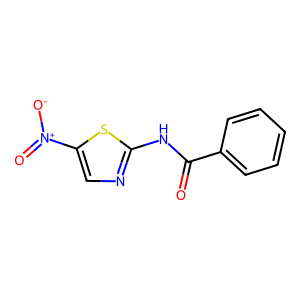

In [283]:
sample_and_print(2, properties)

In [284]:
test_mol = Chem.MolFromSmiles("CC(O)(COc1ccc(OC(F)(F)F)cc1)C(=O)Nc1ccc(C#N)cc1C(F)(F)F")

In [287]:
test_mol
print(Descriptors.MolLogP(test_mol))
print(Descriptors.MolWt(test_mol))

4.244180000000002
448.3190000000001


COc1cc(C=O)cc(-c2cc(C=O)cc(OC)c2O)c1O


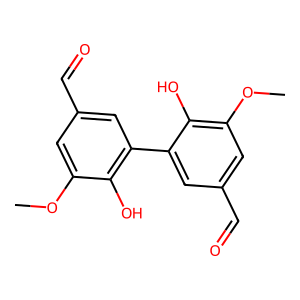

CCN(CC)C(=O)/C=C/c1ccc(OCc2ccccc2)c(OC)c1


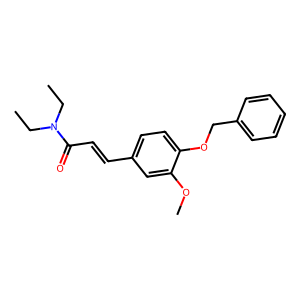

N#Cc1ccc(S(=O)(=O)NNc2ccc(Br)cc2)cc1


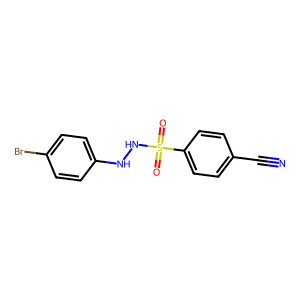

CCCCOC(=O)CSc1nc(N)c(C#N)c(-c2ccc(OCC)cc2)c1C#N


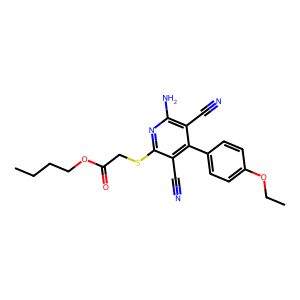

CNC(=O)/C(=C/c1ccc(OC)cc1)c1ccccc1


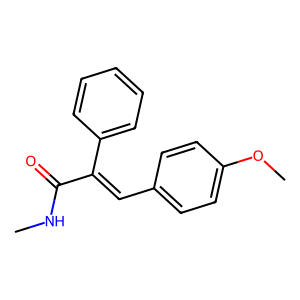

CCC1C(=O)N2C=CSC2N(CC)C1=O


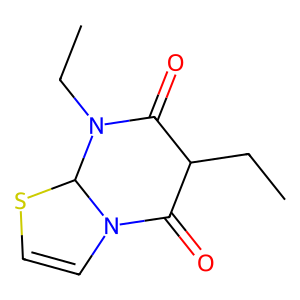

O=C(N/N=C/c1ccc([N+](=O)[O-])cc1)c1cccnc1


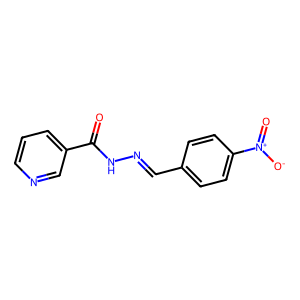

CCOC(=O)c1cc(O)n(-c2ccc(CS(=O)(=O)NC)cc2)n1


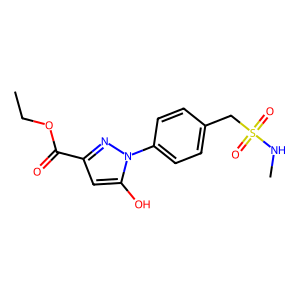

CCN1CCC(c2ccccc2)=C(C(=O)OCC(C)C)C1.O=C(O)C(=O)O


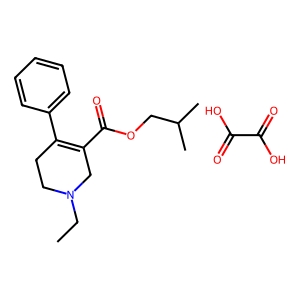

CCOc1noc2c1CNCC2.Cl


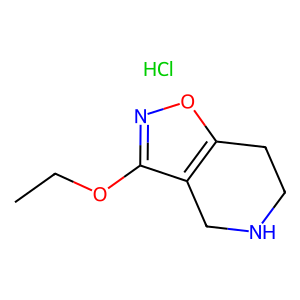

In [277]:
for mol in sampled_properties.canonical_smiles:
    print(mol)
    m = Chem.MolFromSmiles(mol)
    if m:  # Ensure the molecule was created successfully
        img = Draw.MolToImage(m)
        display(img)

In [231]:
properties = [compute_properties(smiles) for smiles in df["canonical_smiles"]]

KeyError: 'canonical_smiles'

In [146]:
df = filterRings(3, df)

TypeError: No registered converter was able to produce a C++ rvalue of type std::basic_string<wchar_t, std::char_traits<wchar_t>, std::allocator<wchar_t> > from this Python object of type DataFrame

In [119]:
# Compute properties for all SMILES
properties = [compute_properties(smiles) for smiles in df["SMILES"]]

In [120]:
# Create DataFrame from computed properties
properties_df = pd.DataFrame(properties)

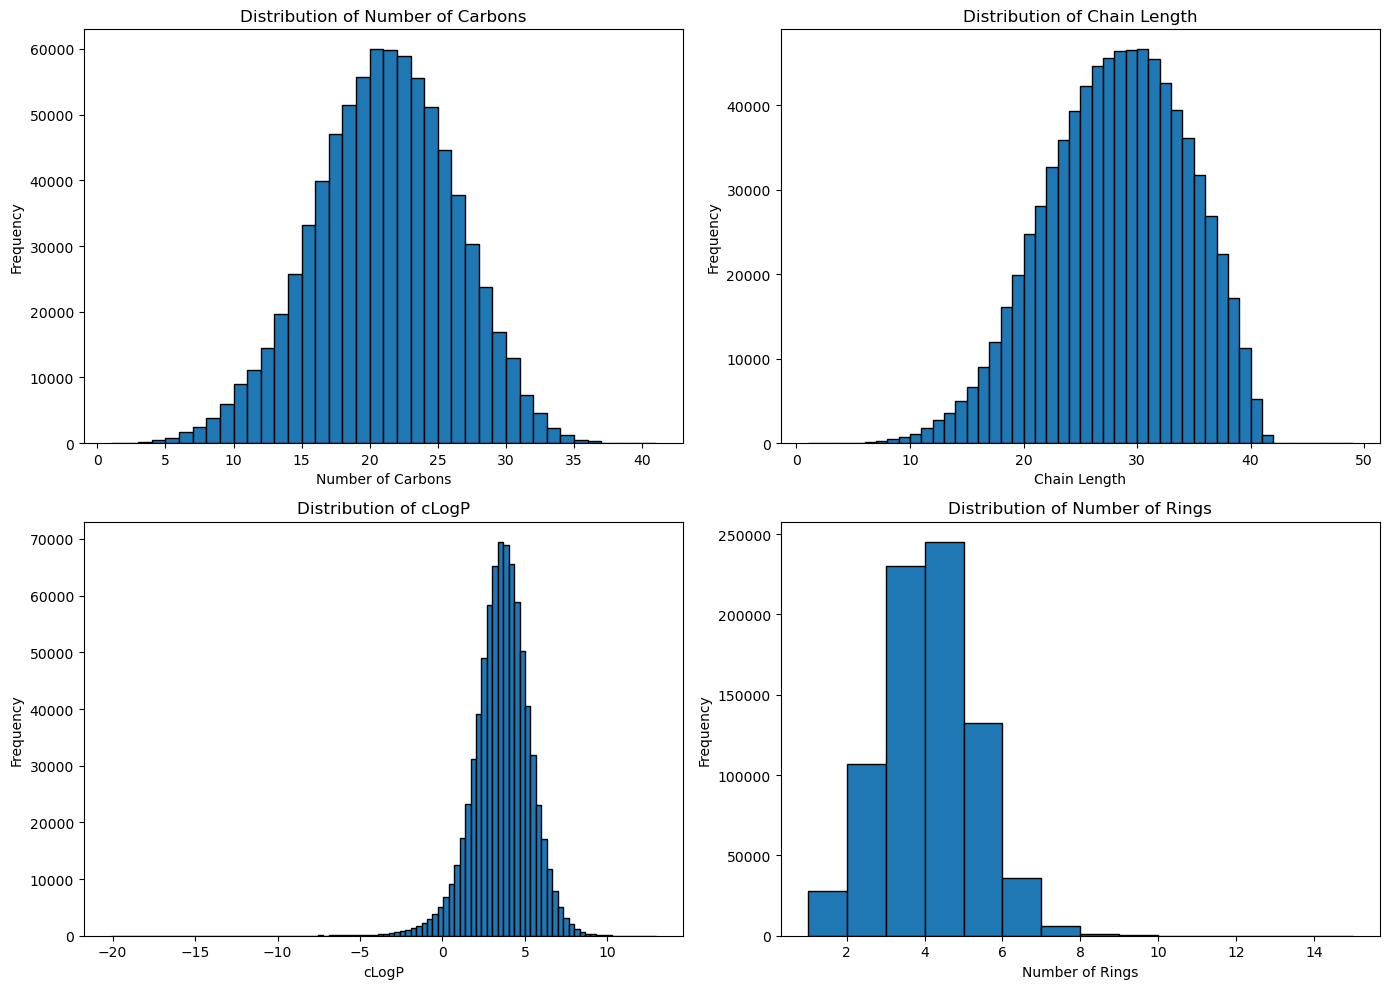

In [131]:
def plot_Dist(df, output_path):
    # Plot distributions
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    # Number of Carbons distribution
    axs[0, 0].hist(
        df["Num_Carbons"].dropna(),
        bins=range(1, df["Num_Carbons"].max() + 2),
        range=[df["Num_Carbons"].min(), df["Num_Carbons"].max()],
        edgecolor="black",
    )
    axs[0, 0].set_title("Distribution of Number of Carbons")
    axs[0, 0].set_xlabel("Number of Carbons")
    axs[0, 0].set_ylabel("Frequency")

    # Chain Length distribution
    axs[0, 1].hist(
        df["Chain_Length"].dropna(),
        bins=range(1, df["Chain_Length"].max() + 2),
        range=[df["Chain_Length"].min(), df["Chain_Length"].max()],
        edgecolor="black",
    )
    axs[0, 1].set_title("Distribution of Chain Length")
    axs[0, 1].set_xlabel("Chain Length")
    axs[0, 1].set_ylabel("Frequency")

    # cLogP distribution
    axs[1, 0].hist(
        df["cLogP"].dropna(),
        bins=100,
        range=[df["cLogP"].min(), df["cLogP"].max()],
        edgecolor="black",
    )
    axs[1, 0].set_title("Distribution of cLogP")
    axs[1, 0].set_xlabel("cLogP")
    axs[1, 0].set_ylabel("Frequency")

    # Number of Rings distribution
    axs[1, 1].hist(
        df["Num_Rings"].dropna(),
        bins=range(1, df["Num_Rings"].max() + 2),
        range=[df["Num_Rings"].min(), df["Num_Rings"].max()],
        edgecolor="black",
    )
    axs[1, 1].set_title("Distribution of Number of Rings")
    axs[1, 1].set_xlabel("Number of Rings")
    axs[1, 1].set_ylabel("Frequency")

    plt.tight_layout()

    fig.savefig(output_path)
    plt.show()


plot_Dist(properties_df, "testTHISSHIT.png")

### THOUGHTS
Filtering the code MW under 550, we get a reduction in molecules from (938551, 1) to (791492, 1), which is still pretty good. The distribution also looks better. Fairly normalized.

In [112]:
MolWeights_df.MW.max()

549.9960000000002

In [64]:
properties_df["cLogP"].max()

180.5171999999962

In [66]:
range(1, properties_df["cLogP"].max() + 2)

TypeError: 'numpy.float64' object cannot be interpreted as an integer

In [69]:
properties_df.cLogP.dtype

dtype('float64')

In [70]:
w = properties_df.cLogP

In [74]:
values, counts = np.unique(w, return_counts=True)

In [76]:
values

array([-113.011  , -113.011  ,  -75.2476 , ...,  111.5501 ,  171.26304,
        180.5172 ])